# CNN Visual Grader (MobileNetV2 Experimentation)
**Objective:** Fine-tune a pre-trained MobileNetV2 model to predict an engineered, log-scaled sales target based solely on product images. 

**Professional Standards Implemented:**
* Target distribution EDA.
* 80/20 `train_test_split`.
* Data augmentation to prevent overfitting.
* Early stopping and model checkpointing to preserve the best weights.

## Setup and Imports

In [4]:
# Imports:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [5]:
# Ensuring GPU Memory Growth:
gpu = tf.config.experimental.list_physical_devices('GPU')

if gpu:
    try:
        for g in gpu:
            tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print(e)

print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(gpu)}")

TensorFlow version: 2.20.0
Num GPUs Available: 1


## Data Loading and Validation

In [16]:
# Data Directory Paths:
IMAGE_DIR= os.path.abspath('../data/images_10k/')
TARGET_CSV= os.path.abspath('../data/processed/cnn_proxy_targets_10k.csv')

In [17]:
# Loading Data:
df= pd.read_csv(TARGET_CSV,
                dtype= {'article_id': str})
df['file_path']= df['article_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))

In [18]:
df.head()

,article_id,total_sales,total_sales_log,cnn_target_scaled,file_path
0,0111593001,13888,9.538852,0.873014,/home/shail/trendsight/data/images_10k/0111593...
1,0112679048,3,1.386294,0.068409,/home/shail/trendsight/data/images_10k/0112679...
2,0114428030,101,4.624973,0.388046,/home/shail/trendsight/data/images_10k/0114428...
3,0118458004,230,5.442418,0.468722,/home/shail/trendsight/data/images_10k/0118458...
4,0118458028,35,3.583519,0.285261,/home/shail/trendsight/data/images_10k/0118458...


In [20]:
df.shape

(10000, 5)

In [22]:
# Verifying Image Existence:
df['image_exists']= df['file_path'].apply(os.path.exists)
missing_count= (~df['image_exists']).sum()
print(f"Missing Images Dropped: {missing_count}")
df= df[df['image_exists']].copy()

print(f"DataFrame Shape After Dropping Missing Images: {df.shape}")

Missing Images Dropped: 39
DataFrame Shape After Dropping Missing Images: (9961, 6)


## Target Variable Analysis

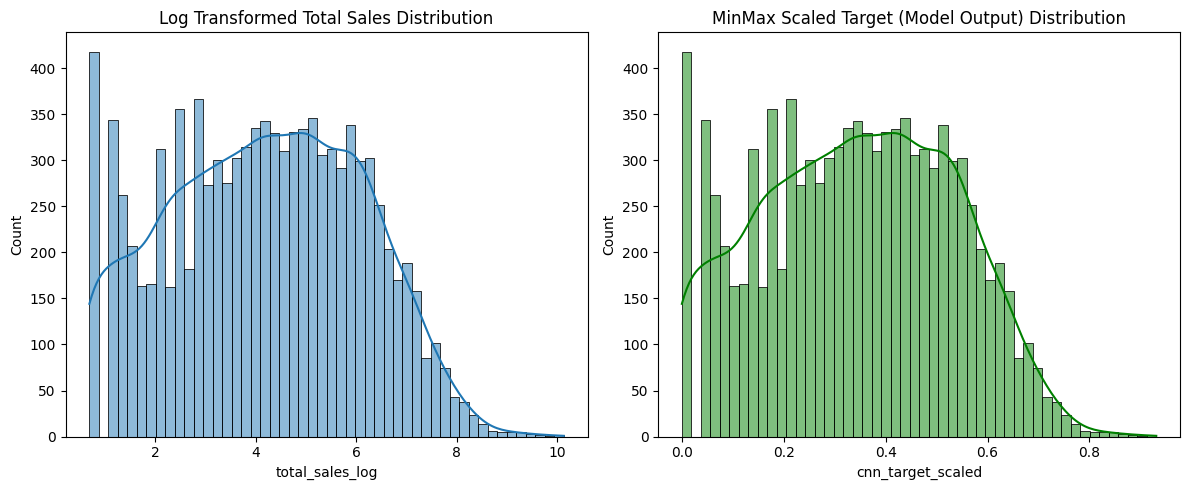

In [23]:
# Visualizing Target Variable to Ensure already applied log-transform + MinMax Scale is healthy:

plt.figure(figsize= (12,5))

plt.subplot(1,2,1)
sns.histplot(df['total_sales_log'], bins= 50, kde= True)
plt.title('Log Transformed Total Sales Distribution')

plt.subplot(1,2,2)
sns.histplot(df['cnn_target_scaled'], bins= 50, kde= True, color= 'green')
plt.title('MinMax Scaled Target (Model Output) Distribution')

plt.tight_layout()
plt.show()

## Train Test Split

In [27]:
train_df, test_df= train_test_split(df, test_size= 0.2, random_state= 42)
print(f"Train DataFrame Shape: {train_df.shape}")
print(f"Test DataFrame Shape: {test_df.shape}")

Train DataFrame Shape: (7968, 6)
Test DataFrame Shape: (1993, 6)


## Data Pipleline with Data Augmentation

In [28]:
# Variables:
BATCH_SIZE= 32
IMG_SIZE= (224, 224)

In [29]:
# Data Augmentation Layer:
data_augmetnation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

I0000 00:00:1782794476.933468    8610 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [30]:
# Processing Images:
def process_image(file_path, label):

    # Read the image from the file path
    image = tf.io.read_file(file_path)
    # Decode the image to a tensor
    image = tf.image.decode_jpeg(image, channels= 3)
    # Resize the image to the desired size
    image = tf.image.resize(image, IMG_SIZE)
    # Normalize the pixel values to [-1, 1] as per MobileNetV2 requirements
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [33]:
# Building TensorFlow Dataset:
def build_dataset(dataframe, is_training= True):
    paths= dataframe['file_path'].values
    labels= dataframe['cnn_target_scaled'].values

    ds= tf.data.Dataset.from_tensor_slices((paths, labels))
    ds= ds.map(process_image, num_parallel_calls= tf.data.AUTOTUNE)

    if is_training:

        # Shuffling and Augmenting Data only while Training:
        ds= ds.shuffle(buffer_size= len(dataframe))
        ds= ds.map(lambda x, y: (data_augmetnation(x, training= True), y), 
                   num_parallel_calls= tf.data.AUTOTUNE)
    
    ds= ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

In [34]:
# Training and Validation Datasets:
train_ds= build_dataset(train_df, is_training= True)
val_ds= build_dataset(test_df, is_training= False)

## Model Architecture

In [35]:
# Loading Base Model:
base_model= MobileNetV2(weights= 'imagenet', include_top= False, input_shape= (224, 224, 3))

# Freezing base Model:
base_model.trainable= False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


In [36]:
# Model Architecture:
inputs= Input(shape= (224, 224, 3))
x= base_model(inputs, training= False)
x= GlobalAveragePooling2D()(x)
x= Dropout(0.2)(x)
x= Dense(128, activation= 'relu')(x)
x= Dropout(0.2)(x)

outputs= Dense(1, activation= 'linear')(x)

model= Model(inputs, outputs)

model.compile(
    optimizer= Adam(learning_rate= 0.001),
    loss= 'mse',
    metrics= ['mae']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Callbacks and Model Training

In [37]:
# Setting up Model Checkpoint Path:
checkpoint_path= os.path.abspath('../data/processed/best_visual_grader.h5')

In [39]:
# Model Callbacks:
callbacks= [
    EarlyStopping(monitor= 'val_loss',
                  patience= 3,
                  restore_best_weights= True,
                  verbose= 1),
    
    ModelCheckpoint(filepath= checkpoint_path,
                    monitor= 'val_loss',
                    save_best_only= True,
                    verbose= 1),

    ReduceLROnPlateau(monitor= 'val_loss',
                      factor= 0.2,
                      patience= 2,
                      min_lr= 1e-6,
                      verbose= 1)
]

In [40]:
# Model Training:
history= model.fit(
    train_ds,
    validation_data= val_ds,
    epochs= 50,
    callbacks= callbacks
)

Epoch 1/50


2026-06-30 06:09:48.049229: I external/local_xla/xla/service/service.cc:163] XLA service 0x771f9404f2b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-30 06:09:48.049417: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-06-30 06:09:48.294608: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-30 06:09:49.262299: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-06-30 06:09:49.440065: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-30 06:09:50.

237/249 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2761 - mae: 0.3556

2026-06-30 06:10:13.388964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 06:10:13.559740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.04275, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5


...


Epoch 4: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.0317 - mae: 0.1456 - val_loss: 0.0327 - val_mae: 0.1505 - learning_rate: 0.0010
Epoch 5/50
215/249 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0303 - mae: 0.1434
Epoch 5: val_loss did not improve from 0.03269
249/249 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0309 - mae: 0.1445 - val_loss: 0.0335 - val_mae: 0.1531 - learning_rate: 0.0010
Epoch 6/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0302 - mae: 0.1426
Epoch 6: val_loss improved from 0.03269 to 0.03248, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 6: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0295 - mae: 0.1402 - val_loss: 0.0325 - val_mae: 0.1503 - learning_rate: 0.0010
Epoch 7/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0277 - mae: 0.1351
Epoch 7: val_loss did not improve from 0.03248
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0295 - mae: 0.1401 - val_loss: 0.0340 - val_mae: 0.1547 - learning_rate: 0.0010
Epoch 8/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0289 - mae: 0.1391
Epoch 8: val_loss improved from 0.03248 to 0.03246, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 8: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0288 - mae: 0.1387 - val_loss: 0.0325 - val_mae: 0.1512 - learning_rate: 0.0010
Epoch 9/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0274 - mae: 0.1347
Epoch 9: val_loss improved from 0.03246 to 0.03182, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 9: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0278 - mae: 0.1360 - val_loss: 0.0318 - val_mae: 0.1496 - learning_rate: 2.0000e-04
Epoch 10/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0274 - mae: 0.1356
Epoch 10: val_loss improved from 0.03182 to 0.03128, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 10: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0276 - mae: 0.1357 - val_loss: 0.0313 - val_mae: 0.1480 - learning_rate: 2.0000e-04
Epoch 11/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0276 - mae: 0.1358
Epoch 11: val_loss did not improve from 0.03128
249/249 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0273 - mae: 0.1351 - val_loss: 0.0314 - val_mae: 0.1484 - learning_rate: 2.0000e-04
Epoch 12/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0264 - mae: 0.1323
Epoch 12: val_loss did not improve from 0.03128

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0269 - mae: 0.1339 - val_loss: 0.0317 - val_mae: 0.1487 - learning_rate: 2.0000e-04
Epoch 13/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0277 - mae: 0.1353
Epoch 13: val_loss did not improve from 0.03128
249/249 ━━━━━━━━━━━━━

# Model Evaluation and Learning Curves

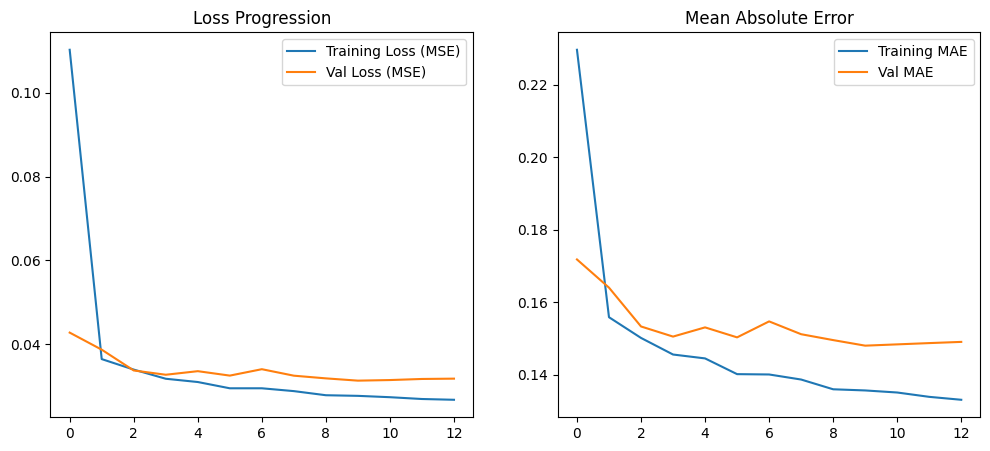

In [41]:
# Plotting Training History:
plt.figure(figsize= (12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label= 'Training Loss (MSE)')
plt.plot(history.history['val_loss'], label= 'Val Loss (MSE)')
plt.legend()
plt.title('Loss Progression')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label= 'Training MAE')
plt.plot(history.history['val_mae'], label= 'Val MAE')
plt.legend()
plt.title('Mean Absolute Error')

plt.show()

In [42]:
# Model Evaluation on the Best Restored Weights:
val_loss, val_mae= model.evaluate(val_ds)
print(f"Final Validation MAE: {val_mae:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0313 - mae: 0.1480
Final Validation MAE: 0.1480
Final Validation Loss: 0.0313
